In [1]:
# Environment check — run this first to diagnose hangs
import sys
import platform
from importlib import util
from importlib import metadata

print('Python executable:', sys.executable)
print('Python version:', sys.version)
print('Platform:', platform.platform())

# torch
if util.find_spec('torch') is not None:
    import torch
    try:
        print('torch version:', torch.__version__)
        print('torch cuda available:', torch.cuda.is_available())
    except Exception as e:
        print('Error querying torch:', e)
else:
    print('torch: not installed')

# tensorflow (check package metadata first to avoid heavy import if missing)
try:
    tf_pkg = metadata.version('tensorflow')
    print('tensorflow package installed, version:', tf_pkg)
    try:
        import tensorflow as tf
        try:
            gpus = tf.config.list_physical_devices('GPU')
            print('tf.__version__:', tf.__version__)
            print('TF GPUs:', gpus)
        except Exception as e:
            print('TensorFlow imported but GPU query failed:', e)
    except Exception as e:
        print('TensorFlow package present but import failed:', e)
except metadata.PackageNotFoundError:
    print('tensorflow: not installed')

Python executable: c:\Users\yashi\OneDrive\Desktop\ccdetection\.venv\Scripts\python.exe
Python version: 3.13.5 (tags/v3.13.5:6cb20a2, Jun 11 2025, 16:15:46) [MSC v.1943 64 bit (AMD64)]
Platform: Windows-11-10.0.26200-SP0
torch version: 2.12.1+cpu
torch cuda available: False
tensorflow package installed, version: 2.21.0
tf.__version__: 2.21.0
TF GPUs: []


In [2]:
import os
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping, ReduceLROnPlateau
import torch
import torch.nn as nn
import torchvision.transforms as transforms
from torchvision.datasets import ImageFolder
from torchvision.models import densenet121, DenseNet121_Weights
from torch.utils.data import DataLoader, Subset
import torch.optim as optim

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("TensorFlow version:", tf.__version__)
print("PyTorch device:", device)

TensorFlow version: 2.21.0
PyTorch device: cpu


In [3]:
split_dir = r"C:\Users\yashi\Downloads\sipakmed_split"

train_dir = os.path.join(split_dir, "train")
val_dir   = os.path.join(split_dir, "val")
test_dir  = os.path.join(split_dir, "test")

train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(),
    transforms.RandomRotation(15),
    transforms.ColorJitter(brightness=0.3, contrast=0.3, saturation=0.2),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225])
])

val_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225])
])

# Separate dataset objects — fixes the transform bug we had before
train_dataset = ImageFolder(train_dir, transform=train_transform)
val_dataset   = ImageFolder(val_dir,   transform=val_transform)
test_dataset  = ImageFolder(test_dir,  transform=val_transform)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True,  num_workers=2, pin_memory=True)
val_loader   = DataLoader(val_dataset,   batch_size=32, shuffle=False, num_workers=2, pin_memory=True)
test_loader  = DataLoader(test_dataset,  batch_size=32, shuffle=False, num_workers=2, pin_memory=True)

print("Classes:", train_dataset.classes)
print(f"Train: {len(train_dataset)} | Val: {len(val_dataset)} | Test: {len(test_dataset)}")

Classes: ['Dyskeratotic', 'Koilocytotic', 'Metaplastic', 'Parabasal', 'Superficial-Intermediate']
Train: 2832 | Val: 608 | Test: 609


In [4]:
model = densenet121(weights=DenseNet121_Weights.DEFAULT)

# Unfreeze last dense block + classifier
for param in model.parameters():
    param.requires_grad = False

for name, param in model.named_parameters():
    if "denseblock4" in name or "norm5" in name:
        param.requires_grad = True

# Replace classifier
num_features = model.classifier.in_features
model.classifier = nn.Sequential(
    nn.Dropout(p=0.4),
    nn.Linear(num_features, 256),
    nn.ReLU(),
    nn.Dropout(p=0.3),
    nn.Linear(256, len(train_dataset.classes))
)

model = model.to(device)
print(f"Trainable: {sum(p.numel() for p in model.parameters() if p.requires_grad):,}")
print(f"Output classes: {len(train_dataset.classes)}")

Trainable: 2,423,813
Output classes: 5


In [5]:
criterion = nn.CrossEntropyLoss(label_smoothing=0.05)

# Separate LRs for backbone vs head
head_params      = list(model.classifier.parameters())
head_param_ids   = set(id(p) for p in head_params)
backbone_params  = [p for p in model.parameters()
                    if p.requires_grad and id(p) not in head_param_ids]

optimizer = optim.AdamW([
    {"params": backbone_params, "lr": 1e-4},
    {"params": head_params,     "lr": 3e-4}
], weight_decay=1e-4)

scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=8, gamma=0.5)

print("Optimizer ready.")

Optimizer ready.


In [6]:
num_epochs    = 40
best_accuracy = 0.0
train_acc_history = []
val_acc_history   = []
train_loss_history = []

for epoch in range(num_epochs):
    # -------- Train --------
    model.train()
    running_loss = 0.0
    correct, total = 0, 0

    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(images)
        loss    = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        running_loss += loss.item()
        _, predicted  = torch.max(outputs, 1)
        total        += labels.size(0)
        correct      += (predicted == labels).sum().item()

    train_acc  = 100 * correct / total
    epoch_loss = running_loss / len(train_loader)
    scheduler.step()

    # -------- Validate --------
    model.eval()
    correct, total = 0, 0
    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)
            _, predicted   = torch.max(model(images), 1)
            total          += labels.size(0)
            correct        += (predicted == labels).sum().item()

    val_acc = 100 * correct / total

    train_acc_history.append(train_acc)
    val_acc_history.append(val_acc)
    train_loss_history.append(epoch_loss)

    print(f"Epoch {epoch+1:02d}/{num_epochs} | "
          f"Loss: {epoch_loss:.4f} | "
          f"Train Acc: {train_acc:.2f}% | "
          f"Val Acc: {val_acc:.2f}%")

    if val_acc > best_accuracy:
        best_accuracy = val_acc
        torch.save(model.state_dict(), "densenet_sipakmed_best.pt")
        print("  --> Best model saved!")

print(f"\nBest Val Accuracy: {best_accuracy:.2f}%")

c:\Users\yashi\OneDrive\Desktop\ccdetection\.venv\Lib\site-packages\torch\utils\data\dataloader.py:1095: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Epoch 01/40 | Loss: 0.9688 | Train Acc: 68.22% | Val Acc: 87.66%
  --> Best model saved!
Epoch 02/40 | Loss: 0.5543 | Train Acc: 86.62% | Val Acc: 90.95%
  --> Best model saved!
Epoch 03/40 | Loss: 0.4731 | Train Acc: 90.08% | Val Acc: 91.28%
  --> Best model saved!
Epoch 04/40 | Loss: 0.4652 | Train Acc: 90.29% | Val Acc: 92.11%
  --> Best model saved!
Epoch 05/40 | Loss: 0.4523 | Train Acc: 90.96% | Val Acc: 92.43%
  --> Best model saved!
Epoch 06/40 | Loss: 0.4335 | Train Acc: 92.20% | Val Acc: 93.26%
  --> Best model saved!
Epoch 07/40 | Loss: 0.4293 | Train Acc: 92.09% | Val Acc: 93.09%
Epoch 08/40 | Loss: 0.4153 | Train Acc: 92.80% | Val Acc: 94.41%
  --> Best model saved!
Epoch 09/40 | Loss: 0.3953 | Train Acc: 93.89% | Val Acc: 93.59%
Epoch 10/40 | Loss: 0.3955 | Train Acc: 93.26% | Val Acc: 93.91%
Epoch 11/40 | Loss: 0.3869 | Train Acc: 94.39% | Val Acc: 93.59%
Epoch 12/40 | Loss: 0.3745 | Train Acc: 94.88% | Val Acc: 94.90%
  --> Best model saved!
Epoch 13/40 | Loss: 0.3889 |

c:\Users\yashi\OneDrive\Desktop\ccdetection\.venv\Lib\site-packages\torch\utils\data\dataloader.py:1095: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Test Accuracy: 94.25%

                          precision    recall  f1-score   support

            Dyskeratotic       0.92      0.98      0.95       122
            Koilocytotic       0.88      0.89      0.88       124
             Metaplastic       0.96      0.87      0.92       119
               Parabasal       0.97      0.97      0.97       119
Superficial-Intermediate       0.98      0.99      0.99       125

                accuracy                           0.94       609
               macro avg       0.94      0.94      0.94       609
            weighted avg       0.94      0.94      0.94       609



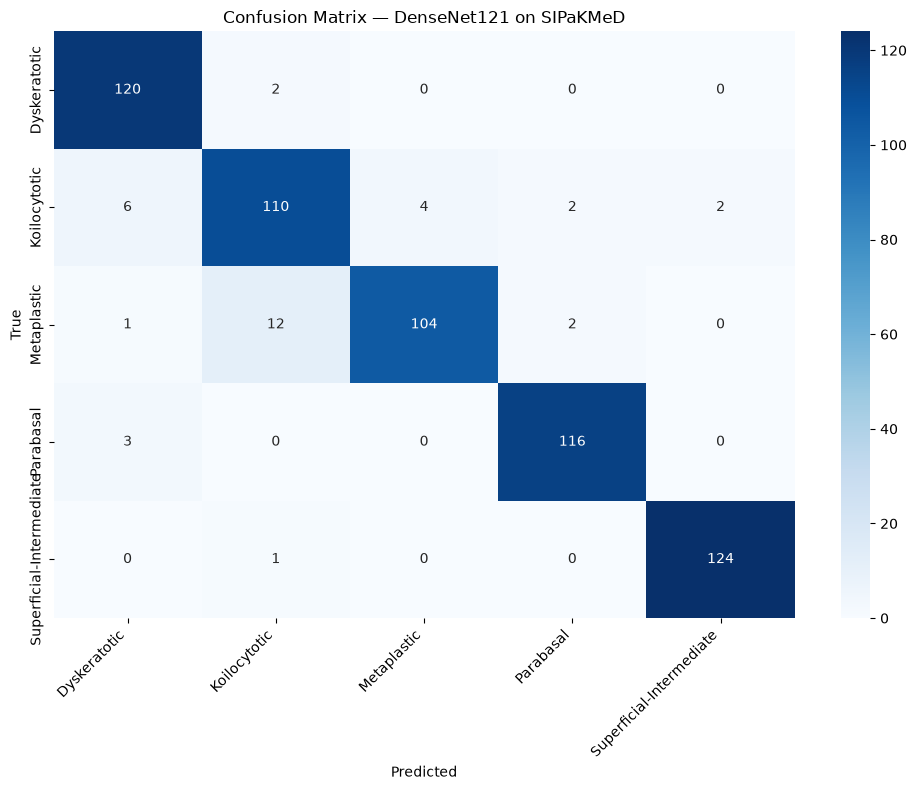

In [7]:
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

model.load_state_dict(torch.load("densenet_sipakmed_best.pt"))
model.eval()

all_preds, all_labels = [], []
with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        _, predicted = torch.max(model(images), 1)
        all_preds.extend(predicted.cpu().numpy())
        all_labels.extend(labels.numpy())

test_acc = 100 * sum(p == l for p, l in zip(all_preds, all_labels)) / len(all_labels)
print(f"Test Accuracy: {test_acc:.2f}%\n")
print(classification_report(all_labels, all_preds, target_names=train_dataset.classes))

# Confusion matrix
cm = confusion_matrix(all_labels, all_preds)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=train_dataset.classes,
            yticklabels=train_dataset.classes)
plt.title("Confusion Matrix — DenseNet121 on SIPaKMeD")
plt.ylabel("True")
plt.xlabel("Predicted")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

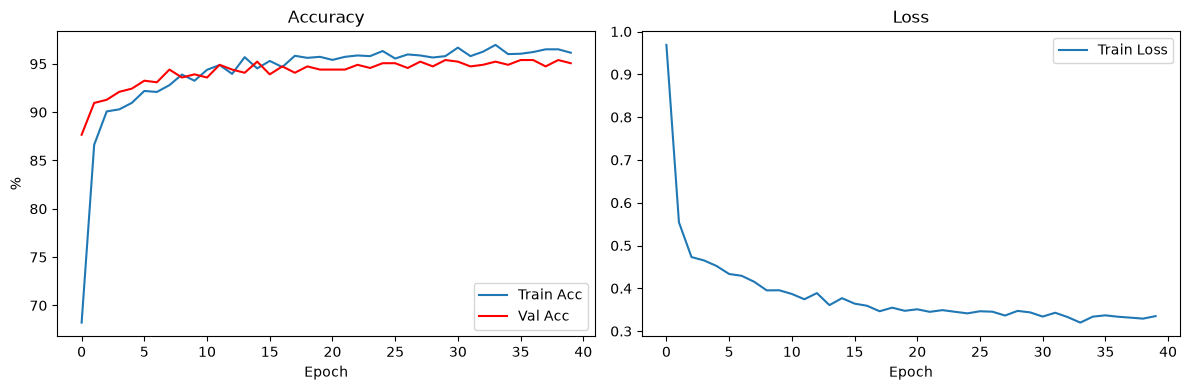

In [8]:
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(train_acc_history, label="Train Acc")
plt.plot(val_acc_history,   label="Val Acc", color="red")
plt.title("Accuracy")
plt.xlabel("Epoch")
plt.ylabel("%")
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(train_loss_history, label="Train Loss")
plt.title("Loss")
plt.xlabel("Epoch")
plt.legend()

plt.tight_layout()
plt.show()

In [9]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn.functional as F
from torchvision import transforms
from PIL import Image
import os

# ---- Grad-CAM implementation ----
class GradCAM:
    def __init__(self, model, target_layer):
        self.model       = model
        self.target_layer = target_layer
        self.gradients   = None
        self.activations = None
        self._register_hooks()

    def _register_hooks(self):
        def forward_hook(module, input, output):
            self.activations = output.detach()

        def backward_hook(module, grad_input, grad_output):
            self.gradients = grad_output[0].detach()

        self.target_layer.register_forward_hook(forward_hook)
        self.target_layer.register_full_backward_hook(backward_hook)

    def generate(self, input_tensor, class_idx=None):
        self.model.eval()
        output = self.model(input_tensor)

        if class_idx is None:
            class_idx = output.argmax(dim=1).item()

        self.model.zero_grad()
        output[0, class_idx].backward()

        # Pool gradients
        pooled_grads = self.gradients.mean(dim=[0, 2, 3])
        cam = self.activations[0]
        for i in range(cam.shape[0]):
            cam[i] *= pooled_grads[i]

        cam = cam.mean(dim=0).cpu().numpy()
        cam = np.maximum(cam, 0)
        cam = (cam - cam.min()) / (cam.max() - cam.min() + 1e-8)
        return cam, class_idx


# ---- Load model ----
model.load_state_dict(torch.load("densenet_sipakmed_best.pt", map_location=device))
model.eval()

# Target the last conv layer in DenseNet denseblock4
target_layer = model.features.denseblock4.denselayer16.conv2
gradcam = GradCAM(model, target_layer)

# ---- Transforms ----
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225])
])

classes = train_dataset.classes

def show_gradcam(image_path):
    # Load image
    img_pil  = Image.open(image_path).convert("RGB")
    img_tensor = transform(img_pil).unsqueeze(0).to(device)

    # Generate CAM
    cam, predicted_idx = gradcam.generate(img_tensor)

    # Resize CAM to image size
    img_np  = np.array(img_pil.resize((224, 224)))
    cam_resized = cv2.resize(cam, (224, 224))
    heatmap = cv2.applyColorMap(np.uint8(255 * cam_resized), cv2.COLORMAP_JET)
    heatmap = cv2.cvtColor(heatmap, cv2.COLOR_BGR2RGB)
    overlay = (0.5 * img_np + 0.5 * heatmap).astype(np.uint8)

    # Plot
    fig, axes = plt.subplots(1, 3, figsize=(14, 4))
    axes[0].imshow(img_np);       axes[0].set_title("Original Image");  axes[0].axis("off")
    axes[1].imshow(heatmap);      axes[1].set_title("Grad-CAM Heatmap"); axes[1].axis("off")
    axes[2].imshow(overlay);      axes[2].set_title(f"Overlay\nPredicted: {classes[predicted_idx]}"); axes[2].axis("off")
    plt.tight_layout()
    plt.show()
    print(f"Predicted class: {classes[predicted_idx]}")


--- True class: Dyskeratotic ---


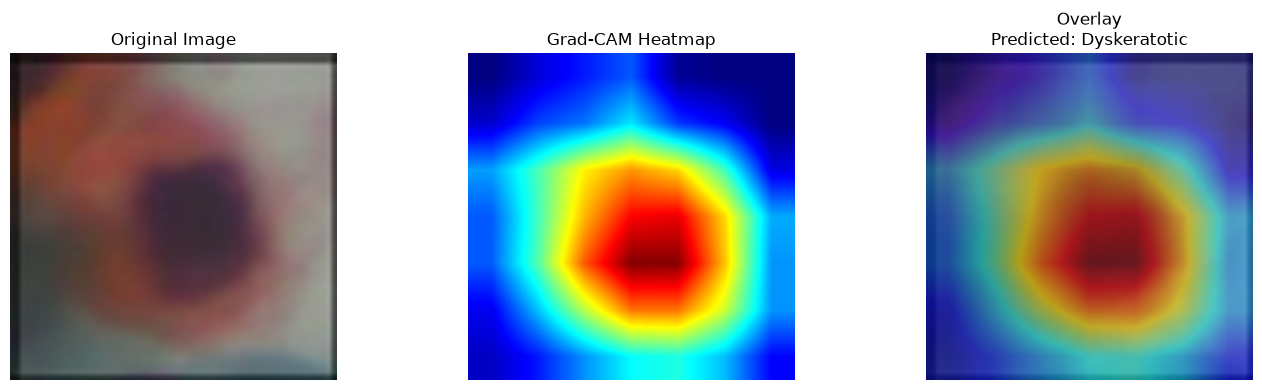

Predicted class: Dyskeratotic

--- True class: Koilocytotic ---


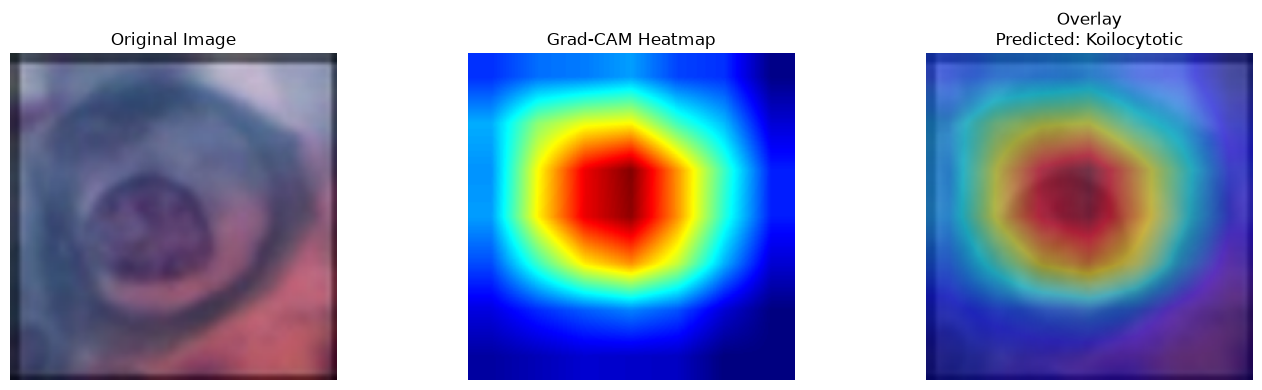

Predicted class: Koilocytotic

--- True class: Metaplastic ---


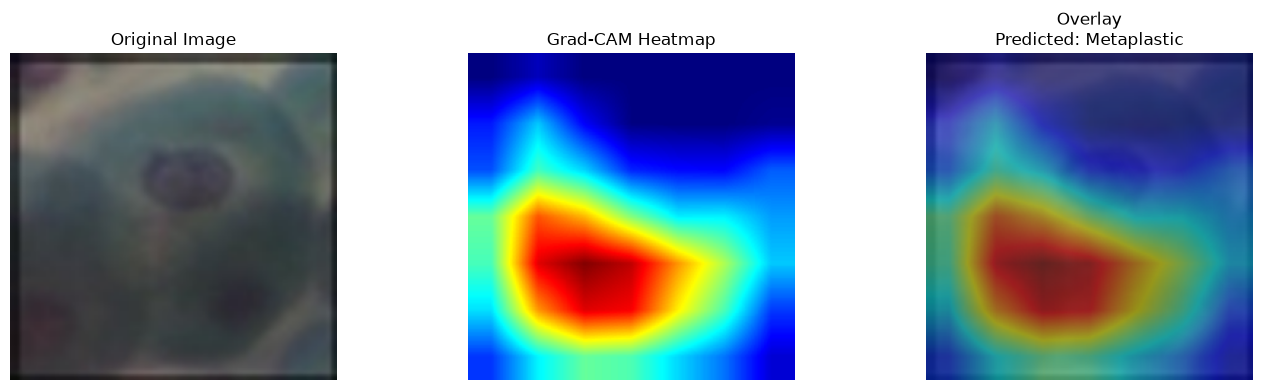

Predicted class: Metaplastic

--- True class: Parabasal ---


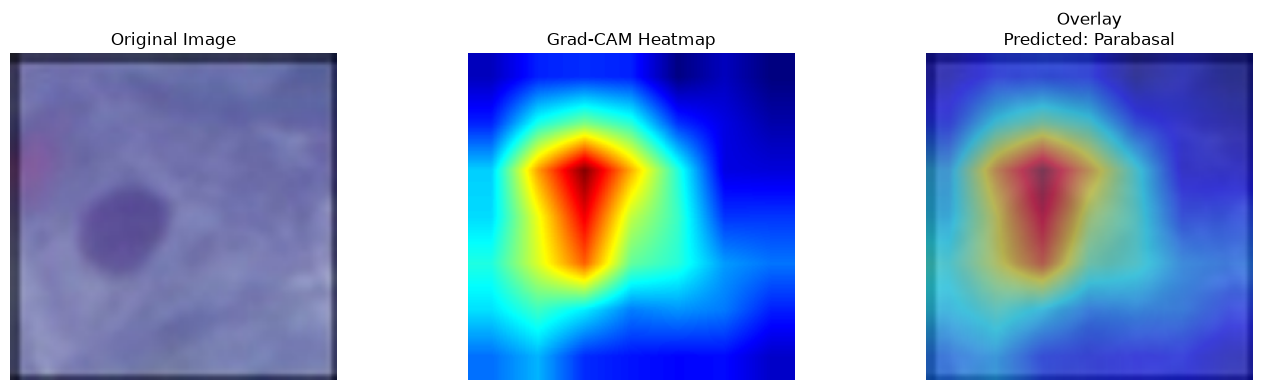

Predicted class: Parabasal

--- True class: Superficial-Intermediate ---


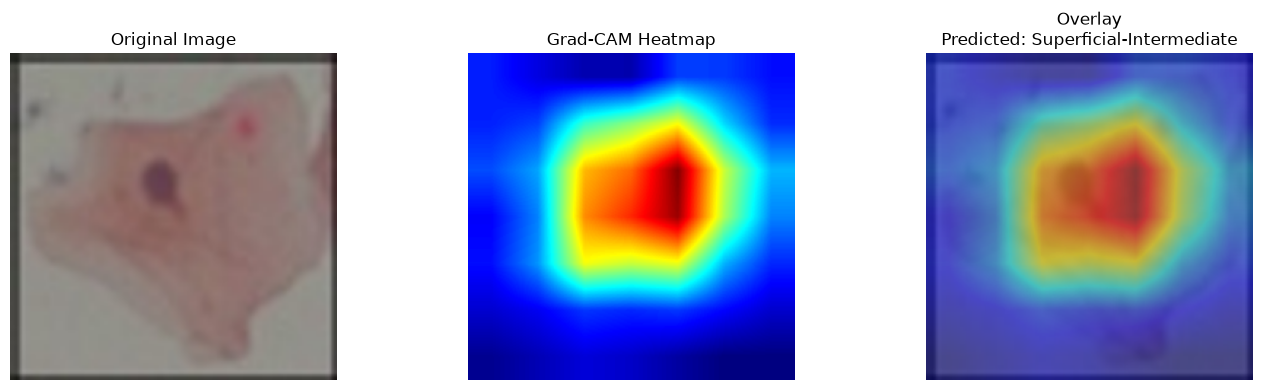

Predicted class: Superficial-Intermediate


In [10]:
test_dir = r"C:\Users\yashi\Downloads\sipakmed_split\test"

# Pick one image from each class
for cls in classes:
    cls_dir    = os.path.join(test_dir, cls)
    sample_img = os.path.join(cls_dir, os.listdir(cls_dir)[0])
    print(f"\n--- True class: {cls} ---")
    show_gradcam(sample_img)


--- True class: Dyskeratotic ---


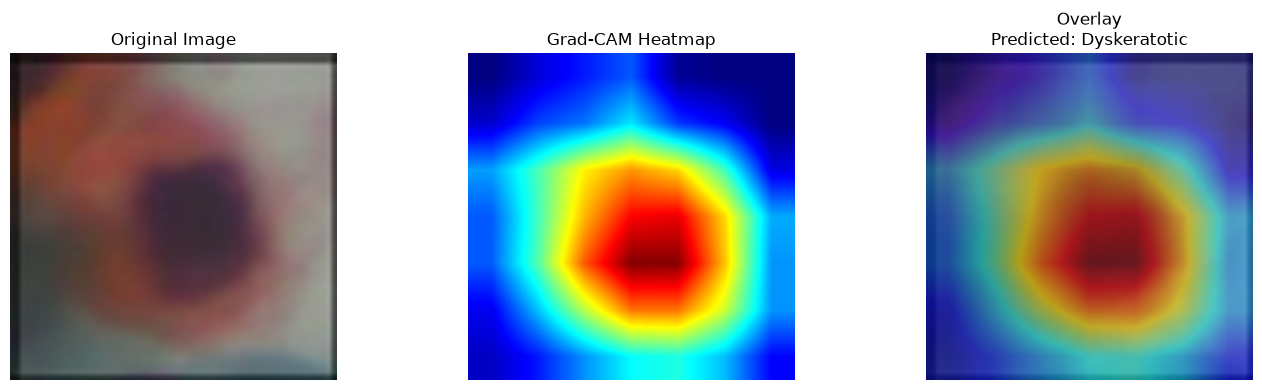

Predicted class: Dyskeratotic

--- True class: Koilocytotic ---


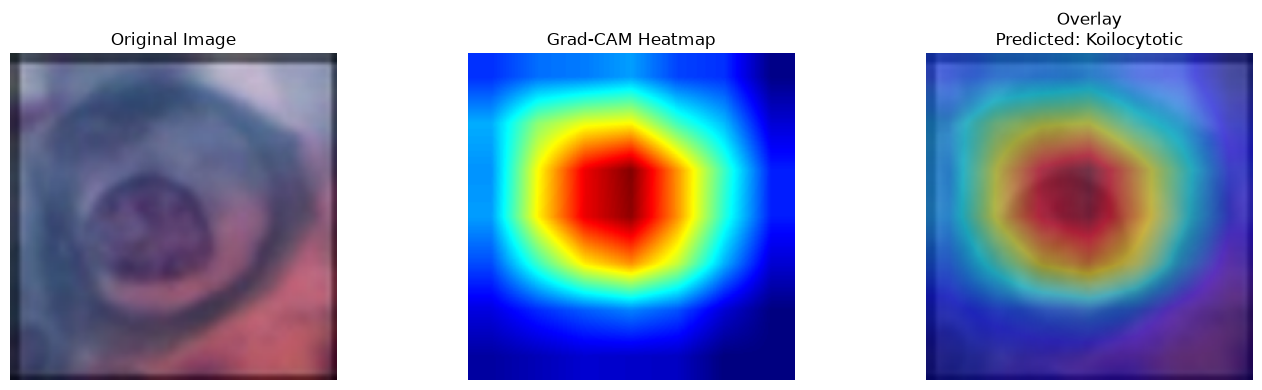

Predicted class: Koilocytotic

--- True class: Metaplastic ---


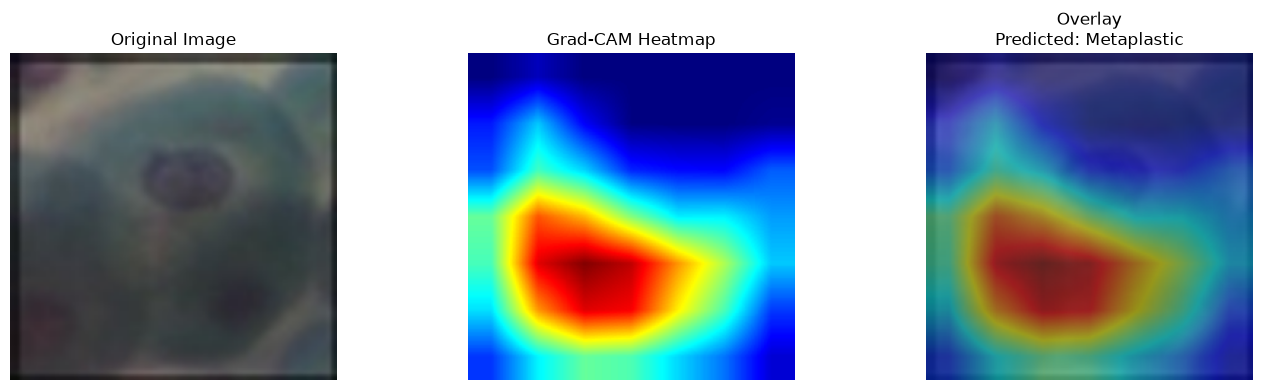

Predicted class: Metaplastic

--- True class: Parabasal ---


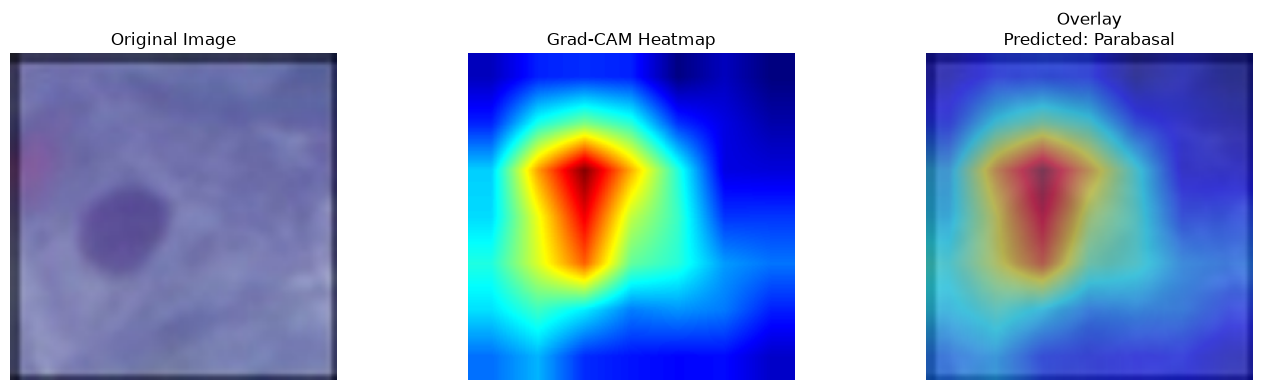

Predicted class: Parabasal

--- True class: Superficial-Intermediate ---


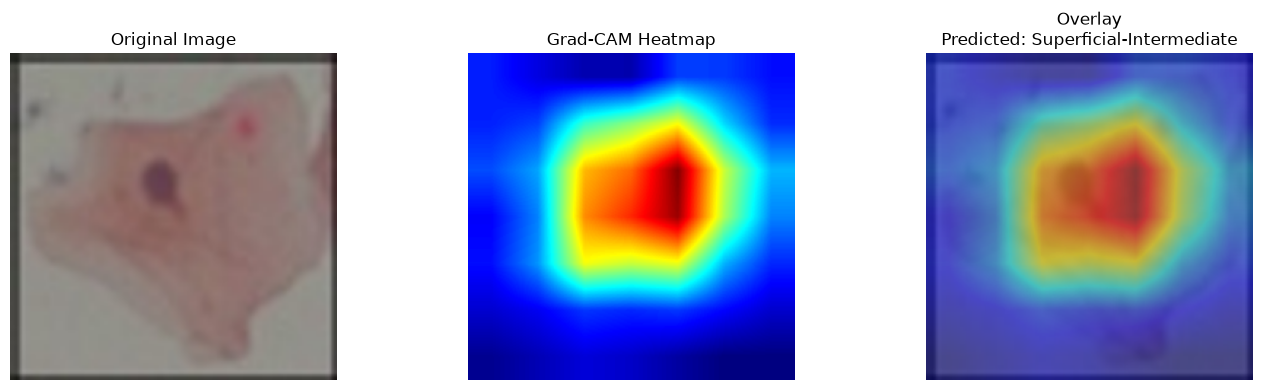

Predicted class: Superficial-Intermediate


In [13]:
# Run Grad-CAM on one image from each class
test_dir = r"C:\Users\yashi\Downloads\sipakmed_split\test"

sample_images = {
    "Dyskeratotic":           "001_02.jpg",
    "Koilocytotic":           "002_01.jpg",
    "Metaplastic":            "001_02.jpg",
    "Parabasal":              "001_02.jpg",
    "Superficial-Intermediate": "001_02.jpg"
}

for cls, filename in sample_images.items():
    image_path = os.path.join(test_dir, cls, filename)
    print(f"\n--- True class: {cls} ---")
    show_gradcam(image_path)

In [14]:
def predict_cell(image_path, show_gradcam=True):
    classes = train_dataset.classes

    # Load & transform
    img_pil    = Image.open(image_path).convert("RGB")
    img_tensor = transform(img_pil).unsqueeze(0).to(device)

    # Get prediction + confidence
    model.eval()
    with torch.no_grad():
        outputs     = model(img_tensor)
        probs       = torch.softmax(outputs, dim=1)[0]
        confidence, predicted_idx = torch.max(probs, 0)

    predicted_class = classes[predicted_idx.item()]
    confidence_pct  = confidence.item() * 100

    # Print all class probabilities
    print(f"\n{'='*45}")
    print(f"  Image: {os.path.basename(image_path)}")
    print(f"{'='*45}")
    print(f"  Predicted : {predicted_class}")
    print(f"  Confidence: {confidence_pct:.2f}%")
    print(f"\n  All class probabilities:")
    for i, cls in enumerate(classes):
        bar    = "█" * int(probs[i].item() * 30)
        marker = " ← predicted" if i == predicted_idx.item() else ""
        print(f"  {cls:<28} {probs[i].item()*100:5.2f}% {bar}{marker}")
    print(f"{'='*45}\n")

    # Show Grad-CAM
    if show_gradcam:
        cam, _ = gradcam.generate(img_tensor, class_idx=predicted_idx.item())
        img_np      = np.array(img_pil.resize((224, 224)))
        cam_resized = cv2.resize(cam, (224, 224))
        heatmap     = cv2.applyColorMap(np.uint8(255 * cam_resized), cv2.COLORMAP_JET)
        heatmap     = cv2.cvtColor(heatmap, cv2.COLOR_BGR2RGB)
        overlay     = (0.5 * img_np + 0.5 * heatmap).astype(np.uint8)

        fig, axes = plt.subplots(1, 3, figsize=(14, 4))
        axes[0].imshow(img_np);  axes[0].set_title("Original");       axes[0].axis("off")
        axes[1].imshow(heatmap); axes[1].set_title("Grad-CAM");        axes[1].axis("off")
        axes[2].imshow(overlay); axes[2].set_title(f"Predicted: {predicted_class}\n{confidence_pct:.1f}% confident"); axes[2].axis("off")
        plt.tight_layout()
        plt.show()

    return predicted_class, confidence_pct


  Image: 002_01.jpg
  Predicted : Koilocytotic
  Confidence: 95.04%

  All class probabilities:
  Dyskeratotic                  0.28% 
  Koilocytotic                 95.04% ████████████████████████████ ← predicted
  Metaplastic                   3.85% █
  Parabasal                     0.45% 
  Superficial-Intermediate      0.39% 



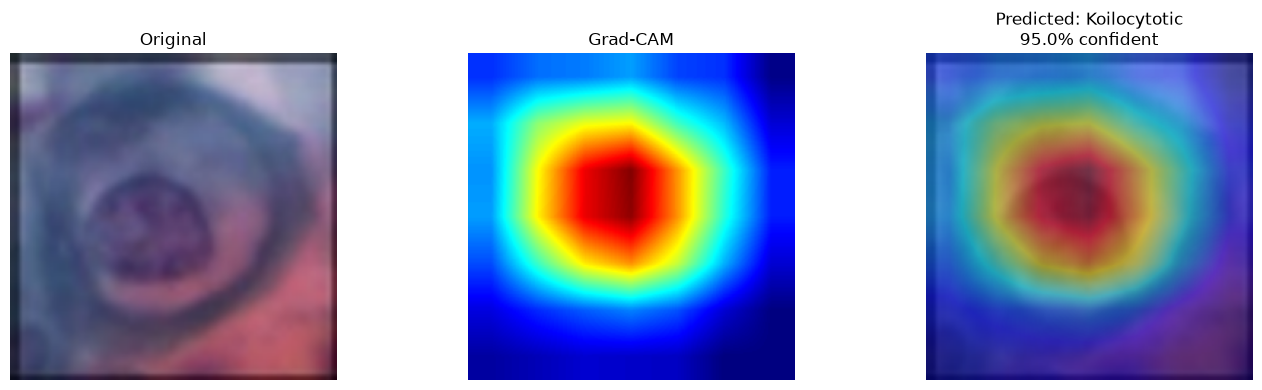

('Koilocytotic', 95.0380027294159)

In [15]:
# Test on any image you want — just change the path
image_path = r"C:\Users\yashi\Downloads\sipakmed_split\test\Koilocytotic\002_01.jpg"
predict_cell(image_path)

In [16]:
print("Running predictions on entire test set...\n")

wrong_predictions = []

for cls in classes:
    cls_dir = os.path.join(test_dir, cls)
    for fname in os.listdir(cls_dir):
        fpath = os.path.join(cls_dir, fname)
        pred_class, conf = predict_cell(fpath, show_gradcam=False)
        if pred_class != cls:
            wrong_predictions.append({
                "file":       fname,
                "true":       cls,
                "predicted":  pred_class,
                "confidence": conf
            })

print(f"\nTotal wrong predictions: {len(wrong_predictions)}")
print(f"Total test images: {sum(len(os.listdir(os.path.join(test_dir, c))) for c in classes)}")
print("\nWrong predictions:")
for w in wrong_predictions:
    print(f"  {w['file']} | True: {w['true']:<28} Predicted: {w['predicted']:<28} Conf: {w['confidence']:.1f}%")

Running predictions on entire test set...


  Image: 001_02.jpg
  Predicted : Dyskeratotic
  Confidence: 98.71%

  All class probabilities:
  Dyskeratotic                 98.71% █████████████████████████████ ← predicted
  Koilocytotic                  0.46% 
  Metaplastic                   0.19% 
  Parabasal                     0.36% 
  Superficial-Intermediate      0.28% 


  Image: 002_09.jpg
  Predicted : Dyskeratotic
  Confidence: 82.03%

  All class probabilities:
  Dyskeratotic                 82.03% ████████████████████████ ← predicted
  Koilocytotic                 15.85% ████
  Metaplastic                   0.29% 
  Parabasal                     0.72% 
  Superficial-Intermediate      1.10% 


  Image: 002_10.jpg
  Predicted : Dyskeratotic
  Confidence: 89.59%

  All class probabilities:
  Dyskeratotic                 89.59% ██████████████████████████ ← predicted
  Koilocytotic                  9.56% ██
  Metaplastic                   0.22% 
  Parabasal                     0.37